# 17 April 2026

In [69]:
import pandas as pd

df = pd.read_csv(r"..\Data\Preprocessed_youtube_ad_revenue_dataset.csv")
df

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,ad_revenue_usd,engagement_rate
0,9936,1221,320,26497.214184,2.862137,228086,1,203.178237,0.155093
1,10017,642,346,15209.747445,23.738069,736015,2,140.880508,0.098632
2,10097,1979,187,57332.658498,26.200634,240534,0,360.134008,0.214519
3,10034,1191,242,31334.517771,11.770340,434482,1,224.638261,0.142814
4,9889,1858,477,15665.666434,6.635854,42030,0,165.514388,0.236121
...,...,...,...,...,...,...,...,...,...
119691,9853,1673,147,42075.704885,25.490195,210818,0,280.986396,0.184715
119692,10128,1709,63,57563.703040,16.229133,878860,4,354.612981,0.174961
119693,10267,700,0,27549.714659,23.822365,576756,5,203.643106,0.068180
119694,10240,1616,106,56967.384382,7.753099,585138,4,351.525811,0.168164


In [70]:
df.corr()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,ad_revenue_usd,engagement_rate
views,1.000000,0.013430,0.014828,0.026004,0.001084,0.000820,-0.001672,0.037869,-0.006126
likes,0.013430,1.000000,-0.014440,0.002519,0.000914,0.005595,0.000036,0.129666,0.969771
comments,0.014828,-0.014440,1.000000,-0.002151,-0.000208,-0.001015,0.001333,0.028548,0.228713
watch_time_minutes,0.026004,0.002519,-0.002151,1.000000,-0.000341,0.004608,0.002677,0.964060,0.001335
video_length_minutes,0.001084,0.000914,-0.000208,-0.000341,1.000000,0.001892,-0.005456,0.000490,0.000833
subscribers,0.000820,0.005595,-0.001015,0.004608,0.001892,1.000000,0.004815,0.005080,0.005194
category,-0.001672,0.000036,0.001333,0.002677,-0.005456,0.004815,1.000000,0.002613,0.000383
ad_revenue_usd,0.037869,0.129666,0.028548,0.964060,0.000490,0.005080,0.002613,1.000000,0.132323
engagement_rate,-0.006126,0.969771,0.228713,0.001335,0.000833,0.005194,0.000383,0.132323,1.000000


In [71]:
df.cov()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,ad_revenue_usd,engagement_rate
views,9985.372174,749.428901,206.609997,3.289458e+04,0.876175,2.363682e+04,-0.285717,234.445475,-0.035112
likes,749.428901,311863.275936,-1124.502203,1.780823e+04,4.126991,9.010873e+05,0.034518,4486.207584,31.062583
comments,206.609997,-1124.502203,19444.498460,-3.796691e+03,-0.234599,-4.081937e+04,0.317847,246.632076,1.829258
watch_time_minutes,32894.584112,17808.228081,-3796.690885,1.602493e+08,-34.938121,1.682029e+07,57.965165,756091.210860,0.969135
video_length_minutes,0.876175,4.126991,-0.234599,-3.493812e+01,65.384199,4.410757e+03,-0.075466,0.245437,0.000387
subscribers,23636.824775,901087.264615,-40819.370808,1.682029e+07,4410.757394,8.316325e+10,2375.134853,90763.032543,85.911428
category,-0.285717,0.034518,0.317847,5.796516e+01,-0.075466,2.375135e+03,2.925865,0.276963,0.000038
ad_revenue_usd,234.445475,4486.207584,246.632076,7.560912e+05,0.245437,9.076303e+04,0.276963,3838.348883,0.470212
engagement_rate,-0.035112,31.062583,1.829258,9.691350e-01,0.000387,8.591143e+01,0.000038,0.470212,0.003290


In [72]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,ad_revenue_usd,engagement_rate
count,119696.000000,119696.000000,119696.000000,119696.000000,119696.000000,119696.000000,119696.000000,119696.000000,119696.000000
mean,9999.817730,1047.258847,261.294296,37540.566821,16.018134,502254.472998,2.497736,252.709665,0.130861
std,99.926834,558.447201,139.443531,12658.962126,8.086050,288380.386641,1.710516,61.954410,0.057357
min,9521.000000,0.000000,0.000000,14659.105562,2.000142,1005.000000,0.000000,126.590603,0.004941
25%,9933.000000,581.000000,146.000000,26951.274051,9.003176,252516.000000,1.000000,199.895130,0.084425
50%,10000.000000,1056.000000,263.000000,37532.253902,16.009460,503594.500000,2.000000,252.677983,0.131462
75%,10067.000000,1525.000000,381.000000,48210.390223,23.027063,752334.000000,4.000000,305.613497,0.178621
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,5.000000,382.768254,0.249554


In [73]:
# PCA not required as there are only 10 features and the correlation is not very high.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA   
import numpy as np

scaler = StandardScaler()
X = df.drop(columns=['ad_revenue_usd'], axis=1)
X_scaled= scaler.fit_transform(X)

decomposition = PCA(n_components=8) 
output = decomposition.fit_transform(X_scaled)
np.cumsum(decomposition.explained_variance_ratio_)

array([0.24916935, 0.37771225, 0.50388581, 0.62966401, 0.75470462,
       0.87863686, 0.99999374, 1.        ])

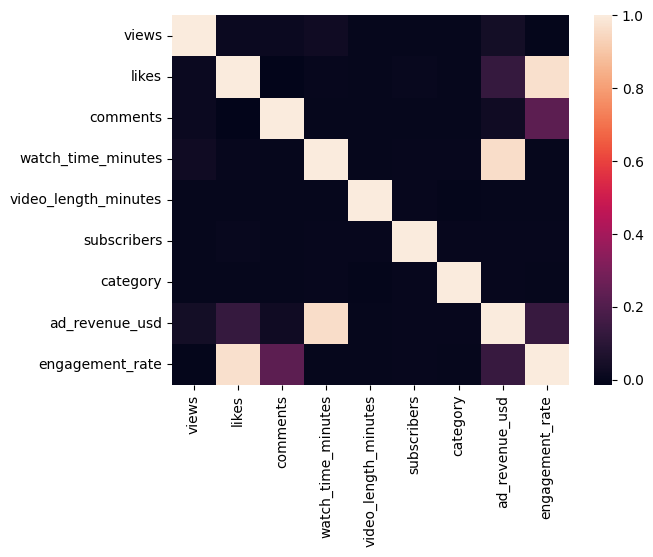

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr()
sns.heatmap(correlation)
plt.show()

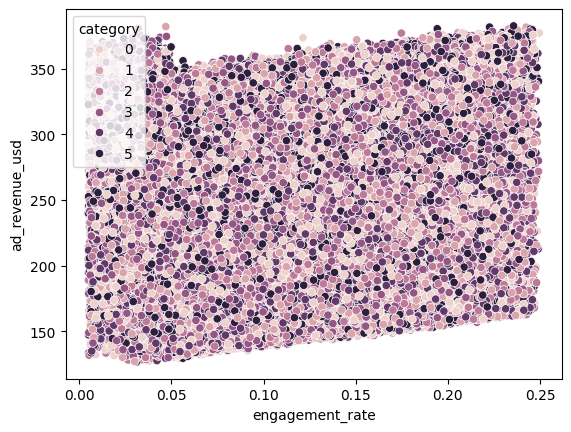

In [75]:
# Weak Relationship
# High engagement does NOT guarantee high revenue
sns.scatterplot(df,x="engagement_rate",y="ad_revenue_usd",hue="category")
plt.show()

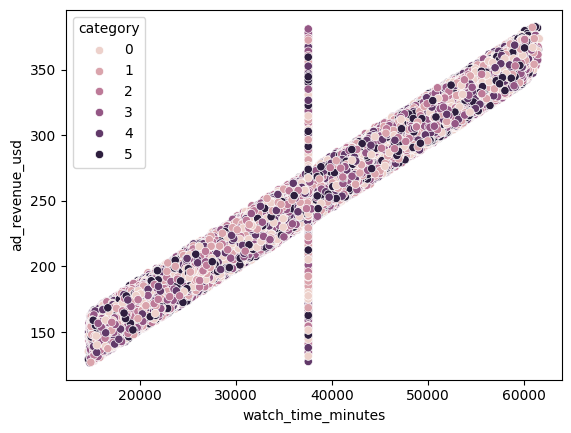

In [76]:
# Strong Relationship
# As watch_time_minutes increases → ad_revenue_usd increases
sns.scatterplot(df,x="watch_time_minutes",y="ad_revenue_usd",hue="category")
plt.show()

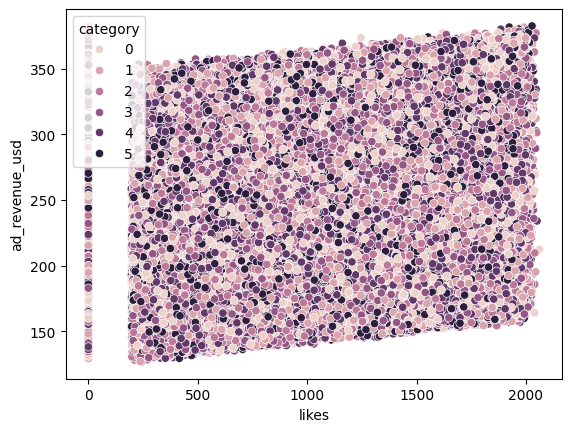

In [77]:
# Moderate Relationship
# slight upward trend
sns.scatterplot(df,x="likes",y="ad_revenue_usd",hue="category")
plt.show()

# Outlier

In [78]:
import pandas as pd

df = pd.read_csv(r"..\Data\Preprocessed_youtube_ad_revenue_dataset.csv")

Q1 = df['watch_time_minutes'].quantile(0.25)
Q3 = df['watch_time_minutes'].quantile(0.75)

IQR=Q3-Q1
upper_fence = Q3 + 1.5 *(IQR)
lower_fence = Q1 - 1.5 *(IQR)

print(f"Q1 :: {Q1}")
print(f"Q3 :: {Q3}")
print(f"IQR :: {IQR}")
print(f"Upper fence :: {upper_fence}")
print(f"Lower fence :: {lower_fence}")

outliers = df[(df['watch_time_minutes'] < lower_fence) | 
              (df['watch_time_minutes'] > upper_fence)]
print(f"length of outliers :: {len(outliers)}")

Q1 :: 26951.274050621003
Q3 :: 48210.39022319855
IQR :: 21259.116172577546
Upper fence :: 80099.06448206486
Lower fence :: -4937.400208245315
length of outliers :: 0


In [79]:
import plotly.express as px
import seaborn as sns

fig = px.box(data_frame=df,x="watch_time_minutes")
fig.show()

In [58]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

views: 864 outliers
likes: 0 outliers
comments: 0 outliers
watch_time_minutes: 0 outliers
video_length_minutes: 0 outliers
subscribers: 0 outliers
category: 0 outliers
device: 0 outliers
ad_revenue_usd: 0 outliers
engagement_rate: 0 outliers


In [80]:
# Mild deviations labeled as outliers due to tight distribution
import plotly.express as px
import seaborn as sns

fig = px.box(data_frame=df,x="views")
fig.show()

# 18 April 2026

In [3]:
import pandas as pd

df = pd.read_csv(r"..\Data\Preprocessed_youtube_ad_revenue_dataset.csv")

Q1 = df['video_length_minutes'].quantile(0.25)
Q3 = df['video_length_minutes'].quantile(0.75)

IQR=Q3-Q1
upper_fence = Q3 + 1.5 *(IQR)
lower_fence = Q1 - 1.5 *(IQR)

print(f"Q1 :: {Q1}")
print(f"Q3 :: {Q3}")
print(f"IQR :: {IQR}")
print(f"Upper fence :: {upper_fence}")
print(f"Lower fence :: {lower_fence}")

Q1 :: 9.003175625117935
Q3 :: 23.02706302695073
IQR :: 14.023887401832797
Upper fence :: 44.06289412969993
Lower fence :: -12.03265547763126


In [4]:
import pandas as pd

df = pd.read_csv(r"..\Data\Preprocessed_youtube_ad_revenue_dataset.csv")

Q1 = df['watch_time_minutes'].quantile(0.25)
Q3 = df['watch_time_minutes'].quantile(0.75)

IQR=Q3-Q1
upper_fence = Q3 + 1.5 *(IQR)
lower_fence = Q1 - 1.5 *(IQR)

print(f"Q1 :: {Q1}")
print(f"Q3 :: {Q3}")
print(f"IQR :: {IQR}")
print(f"Upper fence :: {upper_fence}")
print(f"Lower fence :: {lower_fence}")

Q1 :: 26951.274050621003
Q3 :: 48210.39022319855
IQR :: 21259.116172577546
Upper fence :: 80099.06448206486
Lower fence :: -4937.400208245315
